<a href="https://colab.research.google.com/github/Levi-003/AI-training-Tasks/blob/main/K_nearest_neighbour.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Social_Network_Ads.csv to Social_Network_Ads.csv


In [ ]:
df = pd.read_csv("Social_Network_Ads.csv")

df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
print(df.shape)
print(df.columns)

(400, 5)
Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')


In [ ]:
X = df[["Age", "EstimatedSalary"]]
y = df["Purchased"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = LogisticRegression()

In [ ]:
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8625


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[50  2]
 [ 9 19]]


In [ ]:
new_user = pd.DataFrame({
    "Age": [35],
    "EstimatedSalary": [80000]
})

new_user_scaled = scaler.transform(new_user)

prediction = model.predict(new_user_scaled)

print("Prediction:", prediction[0])

Prediction: 0


In [ ]:
probability = model.predict_proba(new_user_scaled)

print("Probability of No Purchase:", probability[0][0])
print("Probability of Purchase:", probability[0][1])

Probability of No Purchase: 0.773448717540397
Probability of Purchase: 0.226551282459603


In [ ]:
age_coef = abs(model.coef_[0][0])
salary_coef = abs(model.coef_[0][1])

if age_coef > salary_coef:
    print("Age has more influence on purchasgghe decision.")
elif salary_coef > age_coef:
    print("Salary has more influence on purchase decision.")
else:
    print("Age and Salary have equal influence.")

Age has more influence on purchase decision.


In [ ]:
print("Age coefficient:", model.coef_[0][0])
print("Salary coefficient:", model.coef_[0][1])

if abs(model.coef_[0][0]) > abs(model.coef_[0][1]):
    print("Conclusion: Age has a stronger influence on purchase decision.")
else:
    print("Conclusion: Salary has a stronger influence on purchase decision.")

Age coefficient: 1.9650978373553623
Salary coefficient: 1.1350902087855854
Conclusion: Age has a stronger influence on purchase decision.


In [ ]:
import matplotlib.pyplot as plt



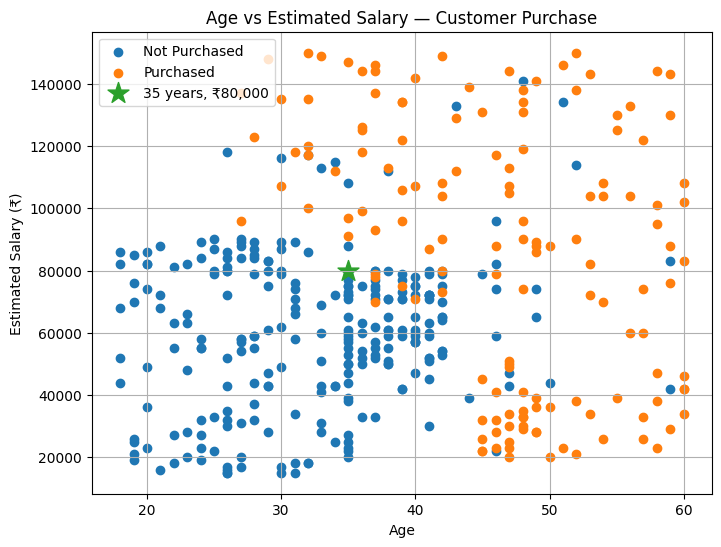

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df[df["Purchased"] == 0]["Age"],
    df[df["Purchased"] == 0]["EstimatedSalary"],
    label="Not Purchased"
)

plt.scatter(
    df[df["Purchased"] == 1]["Age"],
    df[df["Purchased"] == 1]["EstimatedSalary"],
    label="Purchased"
)

# Mark our new customer
plt.scatter(
    35, 80000,
    marker="*",
    s=250,
    label="35 years, ₹80,000"
)

plt.xlabel("Age")
plt.ylabel("Estimated Salary (₹)")
plt.title("Age vs Estimated Salary — Customer Purchase")
plt.legend()
plt.grid(True)

plt.show()